In [1]:
""" 
Section 1 - 2026 Grad Colloquium Learning Package
=====================================================
Description: This notebook will help beginner coders open and inspect data - seciton 4 of the accompanying handbook plotting maps

Version History: 22/05/26, written by A.D. & Claude, 11/06/26 A.D. write script

Notes:
"""

' \nSection 1 - 2026 Grad Colloquium Learning Package\n=====================================================\nDescription: This notebook will help beginner coders open and inspect data - seciton 4 of the accompanying handbook plotting maps\n\nVersion History: 22/05/26, written by A.D. & Claude, 11/06/26 A.D. write script\n\nNotes:\n'

In [2]:
import xarray as xr         # NetCDF & multi-dimensional data
import pandas as pd          # tabular/CSV data
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
from glob import glob        #global path directory

In [3]:
#Open all of the Himawarri maps
files = glob("")

ds = 

ds

/jobfs/170612507.gadi-pbs/ipykernel_1334966/884927063.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(files, combine="nested")
/jobfs/170612507.gadi-pbs/ipykernel_1334966/884927063.py:3: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(files, combine="nested")
/jobfs/170612507.gadi-pbs/ipykernel_1334

<xarray.Dataset> Size: 2GB
Dimensions:                     (time: 6, latitude: 1726, longitude: 2214)
Coordinates:
  * time                        (time) datetime64[ns] 48B 2024-12-31T19:00:00...
  * latitude                    (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                   (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    crs                         int32 4B -2147483647
    surface_global_irradiance   (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    direct_normal_irradiance    (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    surface_diffuse_irradiance  (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    quality_mask                (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    cloud_type                  (time, latitude, longitude) float32 92MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    cloud_optical_depth         (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    solar_elevation             (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    solar_azimuth               (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
    julian_date                 (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 20, 2214), meta=np.ndarray>
Attributes: (12/57)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    date_created:                     20250325T025924Z
    bias_correction_applied:          1
    bias_correction_applied_meaning:  0: not applied; 1:applied
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    history:                          heliosat-4; post_process_p1s.py

In [7]:
# By integer position (first time step)
da_step = ds[""].isel(time=)#this selects the first available timestep

In [5]:
# By label (a specific date/time)
da_step = ds[""].sel(time="")

print(da_step)

<xarray.DataArray 'cloud_type' (latitude: 1726, longitude: 2214)> Size: 15MB
dask.array<getitem, shape=(1726, 2214), dtype=float32, chunksize=(20, 2214), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 7kB -44.5 -44.48 -44.46 ... -10.02 -10.0
  * longitude  (longitude) float32 9kB 112.0 112.0 112.0 ... 156.2 156.2 156.3
    time       datetime64[ns] 8B 2024-12-31T19:00:00
Attributes:
    long_name:      Cloud type
    flag_meanings:  clear low medium high high_thin
    flag_values:    [0 5 6 7 8]
    grid_mapping:   crs
    comment:        Cloud type retrieved from corresponding satellite observa...


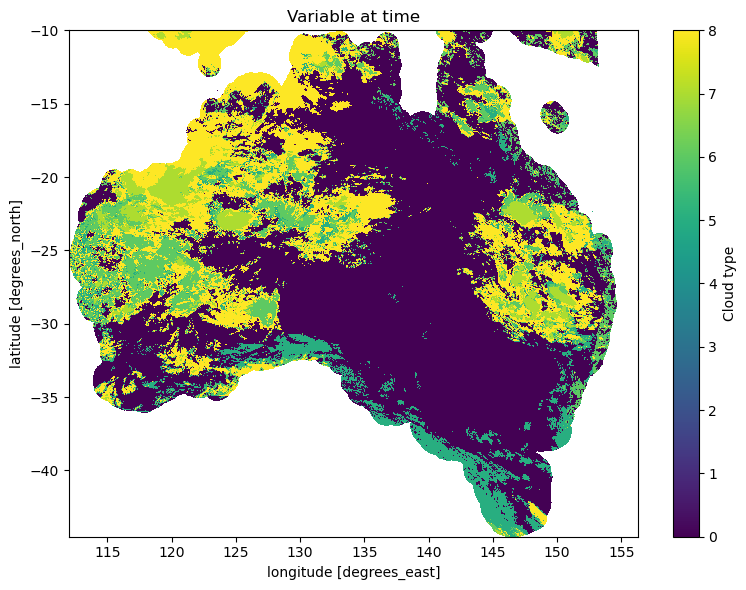

In [8]:
# Plot
plt.figure(figsize=(8, 6))
da.plot()
plt.title('Variable at time')
plt.tight_layout()
plt.show()

## A tried and true plotting script for all your future needs!

In [23]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- USER INPUT ---
FILE = "file_path"   # add your file path
VAR  = "variable_name"   # variable to plot
TIME = "time_select"   # timestep to plot
# -------------------

# Load dataset
ds = xr.open_dataset(FILE)

# Select timestep
da = ds[VAR].sel(time=TIME)

# Plot Set Up
ax = plt.axes(projection=ccrs.PlateCarree())
plt.figure(figsize=(8, 6))

# Call your data
da.plot(ax=ax, transform=ccrs.PlateCarree(),cmap="viridis")

# Add geographic context
ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

# Labels + title
ax.set_title(f"{VAR} at {TIME}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()



ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'argo', 'cfgrib', 'cfradial1', 'datamet', 'era5', 'erddapy', 'funwave', 'furuno', 'gamic', 'gini', 'gmt', 'hpl', 'iris', 'json', 'kerchunk', 'metek', 'ncswan', 'ndbc', 'ndbc_ascii', 'netcdf', 'nexradlevel2', 'octopus', 'odim', 'pydap', 'radolan', 'rainbow', 'rasterio', 'spotter', 'swan', 'triaxys', 'uf', 'wavespectra', 'ww3', 'ww3_station', 'wwm', 'xwaves', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html